# 🔴 Crop Recommendation — Algorithm 4: Support Vector Machine (SVM)

**Dataset:** Crop Recommendation Dataset  
**Source:** https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset  
**Type:** Supervised Learning — Multi-class Classification  
**Algorithm:** Support Vector Machine (SVC)  

---

In [1]:
# ── CELL 1 — Import Libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [2]:
# ── CELL 2 — Load Dataset ──────────────────────────────────────────────────
df = pd.read_csv('/content/Crop_recommendation.csv')
print(f'✅ Dataset loaded!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded!
Shape: 2200 rows × 8 columns


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
# ── CELL 3 — Prepare Features & Target ────────────────────────────────────
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f'Features shape : {X.shape}')
print(f'Target classes : {len(le.classes_)}')
print(f'Classes        : {list(le.classes_)}')

Features shape : (2200, 7)
Target classes : 22
Classes        : ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [4]:
# ── CELL 4 — Feature Scaling (IMPORTANT for SVM) ──────────────────────────
# SVM is sensitive to feature scale — always scale before training.

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('✅ Features scaled with StandardScaler!')
print('After scaling (mean ≈ 0, std ≈ 1):')
print(X_scaled.describe().loc[['mean', 'std']].round(4))

✅ Features scaled with StandardScaler!
After scaling (mean ≈ 0, std ≈ 1):
           N       P       K  temperature  humidity      ph  rainfall
mean -0.0000  0.0000 -0.0000       0.0000   -0.0000 -0.0000    0.0000
std   1.0002  1.0002  1.0002       1.0002    1.0002  1.0002    1.0002


In [5]:
# ── CELL 5 — Train / Test Split ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'Split ratio  : 80% train / 20% test')

Training set : 1760 samples
Test set     : 440 samples
Split ratio  : 80% train / 20% test


In [6]:
# ── CELL 6 — Train Default SVM ────────────────────────────────────────────
svm_default = SVC(kernel='rbf', probability=True, random_state=42)
svm_default.fit(X_train, y_train)

default_acc = accuracy_score(y_test, svm_default.predict(X_test))
print('✅ Default SVM trained!')
print(f'Default Test Accuracy : {default_acc:.4f} ({default_acc*100:.2f}%)')

✅ Default SVM trained!
Default Test Accuracy : 0.9841 (98.41%)


Kernel: linear    →  Accuracy: 0.9818
Kernel: poly      →  Accuracy: 0.9318
Kernel: rbf       →  Accuracy: 0.9841
Kernel: sigmoid   →  Accuracy: 0.8045

✅ Best kernel: rbf (0.9841)


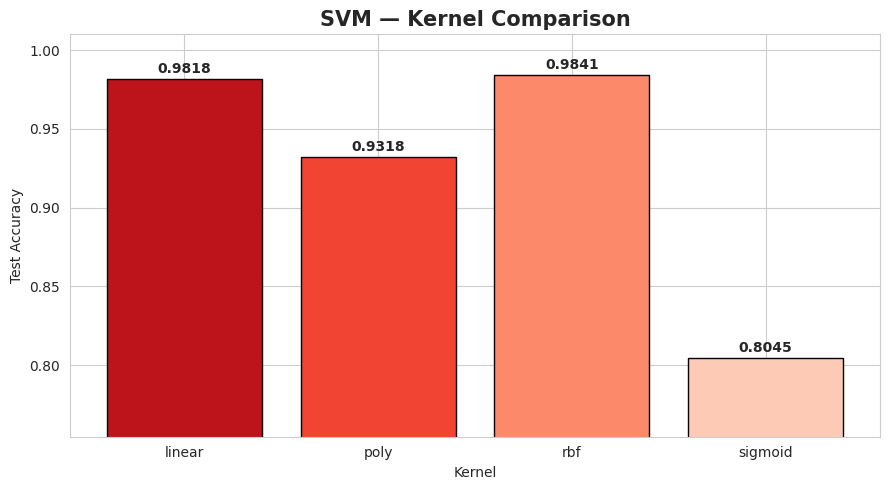

In [7]:
# ── CELL 7 — Kernel Comparison ────────────────────────────────────────────
# Compare all 4 kernels before tuning
kernels     = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_accs = []

for k in kernels:
    svm_tmp = SVC(kernel=k, probability=True, random_state=42)
    svm_tmp.fit(X_train, y_train)
    acc = accuracy_score(y_test, svm_tmp.predict(X_test))
    kernel_accs.append(acc)
    print(f'Kernel: {k:8s}  →  Accuracy: {acc:.4f}')

best_kernel = kernels[np.argmax(kernel_accs)]
print(f'\n✅ Best kernel: {best_kernel} ({max(kernel_accs):.4f})')

plt.figure(figsize=(9, 5))
bars = plt.bar(kernels, kernel_accs,
               color=sns.color_palette('Reds_r', 4), edgecolor='black')
for bar, acc in zip(bars, kernel_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.title('SVM — Kernel Comparison', fontsize=15, fontweight='bold')
plt.xlabel('Kernel')
plt.ylabel('Test Accuracy')
plt.ylim(min(kernel_accs) - 0.05, 1.01)
plt.tight_layout()
plt.show()

In [8]:
# ── CELL 8 — Hyperparameter Tuning with GridSearchCV ──────────────────────
param_grid = {
    'C'      : [0.1, 1, 10, 100],
    'gamma'  : ['scale', 'auto', 0.01, 0.1],
    'kernel' : ['rbf', 'linear']
}

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\n✅ Best Parameters : {grid_search.best_params_}')
print(f'Best CV Accuracy   : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Best Parameters : {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Accuracy   : 0.9869


In [9]:
# ── CELL 9 — Best Model ───────────────────────────────────────────────────
best_svm = grid_search.best_estimator_

print('✅ Best SVM model ready!')
print(f'Kernel : {best_svm.kernel}')
print(f'C      : {best_svm.C}')
print(f'Gamma  : {best_svm.gamma}')

✅ Best SVM model ready!
Kernel : rbf
C      : 100
Gamma  : 0.1


In [10]:
# ── CELL 10 — Predictions ─────────────────────────────────────────────────
y_pred       = best_svm.predict(X_test)
y_pred_proba = best_svm.predict_proba(X_test)

print('✅ Predictions generated!')
print(f'Sample predictions (encoded) : {y_pred[:10]}')
print(f'Sample predictions (labels)  : {list(le.inverse_transform(y_pred[:10]))}')

✅ Predictions generated!
Sample predictions (encoded) : [16  1  6 11 16  3 20  2  1 16]
Sample predictions (labels)  : ['orange', 'banana', 'cotton', 'maize', 'orange', 'chickpea', 'rice', 'blackgram', 'banana', 'orange']


In [11]:
# ── CELL 11 — Cross Validation ────────────────────────────────────────────
cv_scores = cross_val_score(best_svm, X_scaled, y_encoded, cv=10, scoring='accuracy')

print('=== 10-Fold Cross Validation ===')
print(f'Scores  : {np.round(cv_scores, 4)}')
print(f'Mean    : {cv_scores.mean():.4f}')
print(f'Std Dev : {cv_scores.std():.4f}')

=== 10-Fold Cross Validation ===
Scores  : [0.9773 0.9773 0.9909 0.9727 0.9773 1.     0.9818 0.9864 0.9864 0.9955]
Mean    : 0.9845
Std Dev : 0.0084


In [12]:
# ── CELL 12 — Evaluation Metrics ──────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')
roc_auc   = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

print('=' * 45)
print('         SVM — EVALUATION METRICS')
print('=' * 45)
print(f'  Accuracy          : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision (wtd)   : {precision:.4f}')
print(f'  Recall (wtd)      : {recall:.4f}')
print(f'  F1 Score (wtd)    : {f1:.4f}')
print(f'  ROC-AUC (ovr)     : {roc_auc:.4f}')
print(f'  CV Mean Accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 45)

         SVM — EVALUATION METRICS
  Accuracy          : 0.9886  (98.86%)
  Precision (wtd)   : 0.9894
  Recall (wtd)      : 0.9886
  F1 Score (wtd)    : 0.9886
  ROC-AUC (ovr)     : 1.0000
  CV Mean Accuracy  : 0.9845 ± 0.0084


In [13]:
# ── CELL 13 — Classification Report ──────────────────────────────────────
print('=== Full Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== Full Classification Report ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      1.00      0.98        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      0.95      0.97        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00   

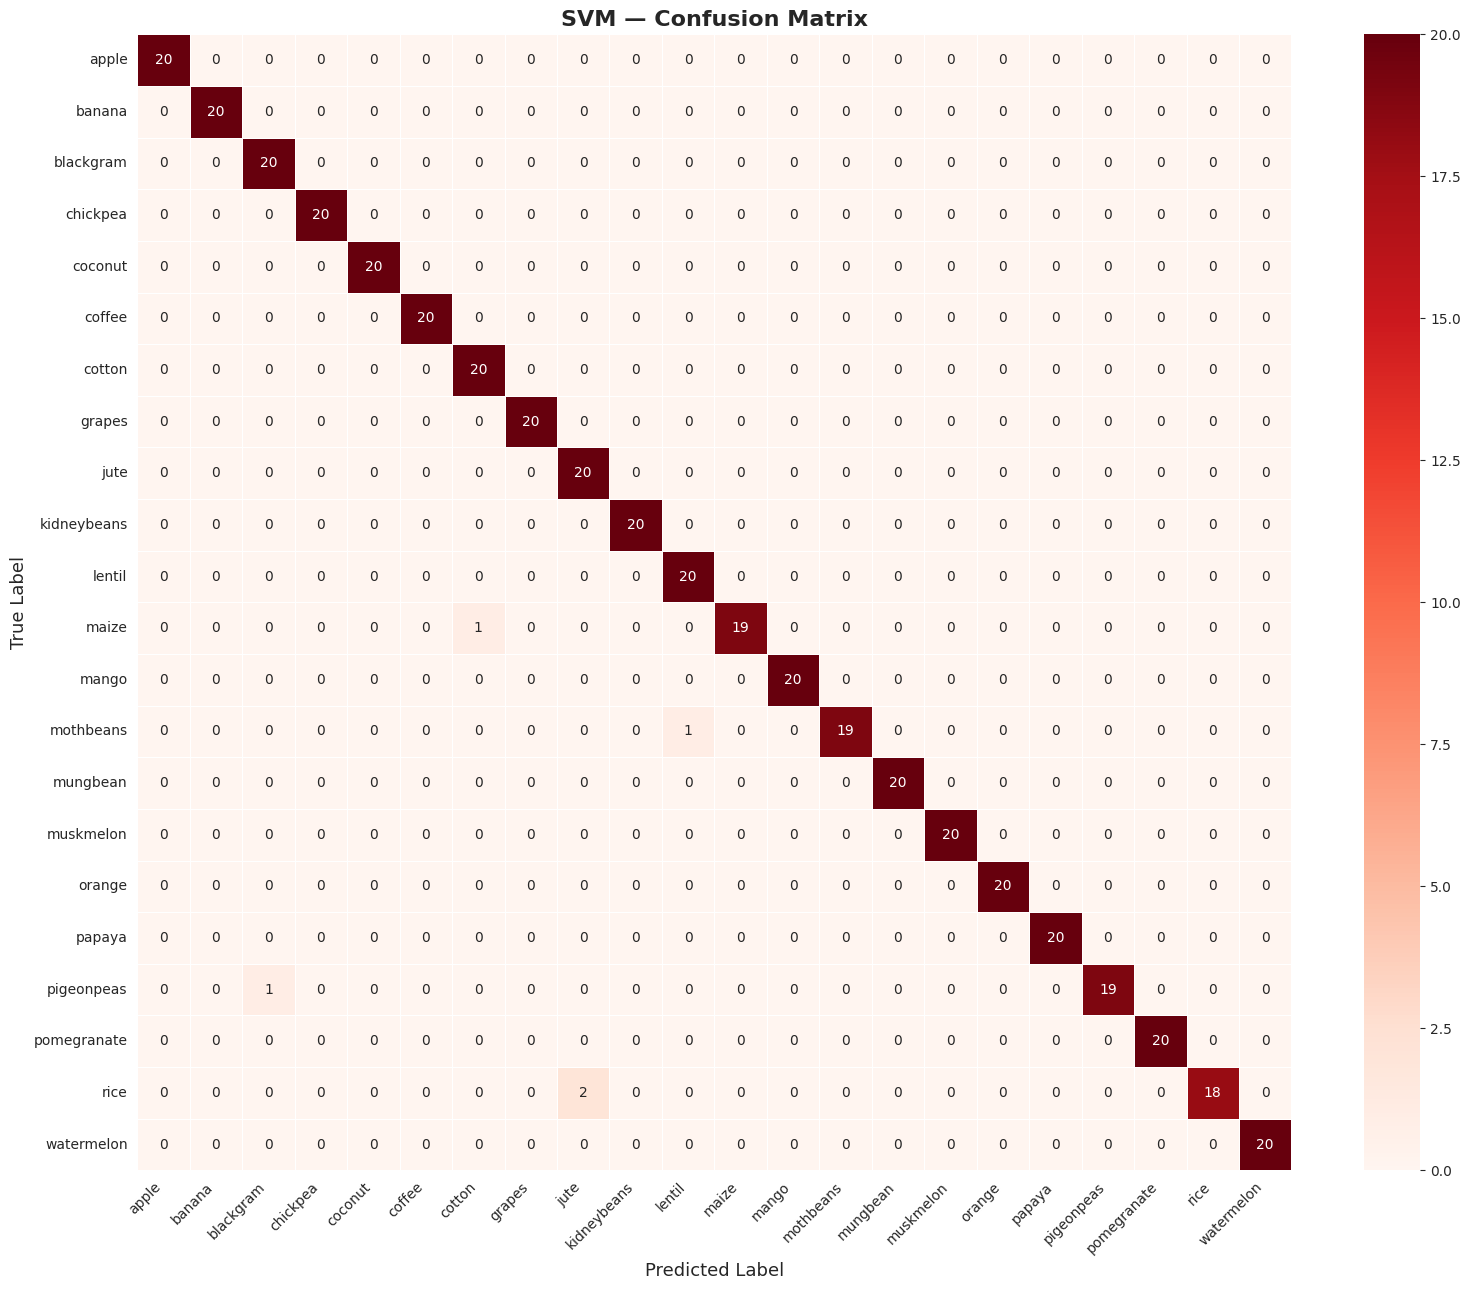

In [14]:
# ── CELL 14 — Confusion Matrix ────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5)
plt.title('SVM — Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

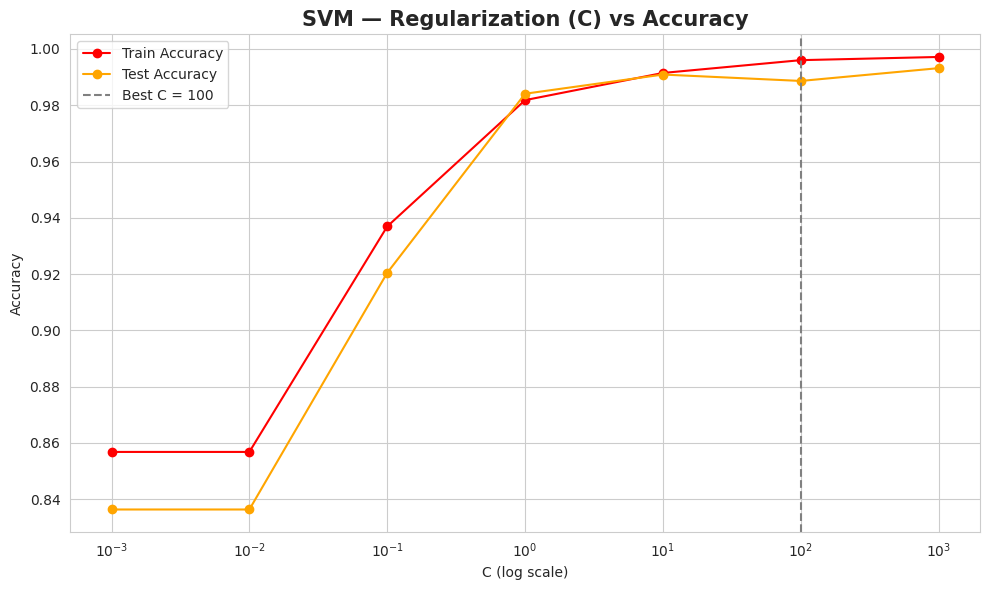

In [15]:
# ── CELL 15 — C Parameter vs Accuracy ────────────────────────────────────
# Shows how the regularization parameter C affects accuracy
C_values   = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_accs = []
test_accs  = []

for c in C_values:
    svm_tmp = SVC(C=c, kernel=best_svm.kernel, gamma=best_svm.gamma,
                  probability=True, random_state=42)
    svm_tmp.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, svm_tmp.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  svm_tmp.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.semilogx(C_values, train_accs, 'o-', color='red',    label='Train Accuracy')
plt.semilogx(C_values, test_accs,  'o-', color='orange', label='Test Accuracy')
plt.axvline(x=best_svm.C, color='gray', linestyle='--', label=f'Best C = {best_svm.C}')
plt.title('SVM — Regularization (C) vs Accuracy', fontsize=15, fontweight='bold')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

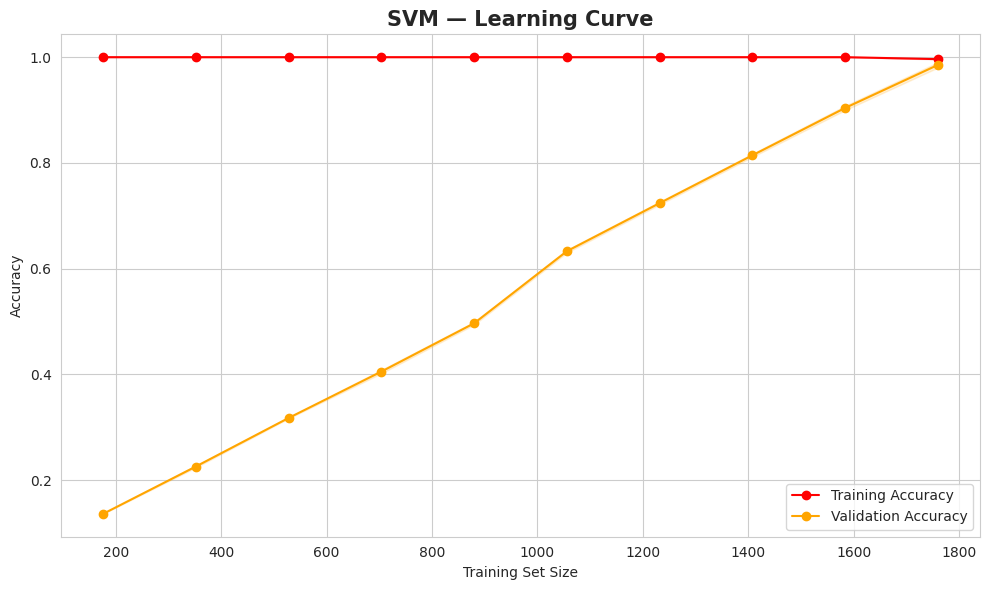

In [16]:
# ── CELL 16 — Learning Curve ──────────────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    best_svm, X_scaled, y_encoded,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='red',    label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='red')
plt.plot(train_sizes, val_mean,   'o-', color='orange', label='Validation Accuracy')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='orange')
plt.title('SVM — Learning Curve', fontsize=15, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# ── CELL 17 — Metrics Summary (Save for Report Comparison) ───────────────
metrics_svm = {
    'Algorithm' : 'SVM',
    'Accuracy'  : round(accuracy, 4),
    'Precision' : round(precision, 4),
    'Recall'    : round(recall, 4),
    'F1 Score'  : round(f1, 4),
    'ROC-AUC'   : round(roc_auc, 4),
    'CV Mean'   : round(cv_scores.mean(), 4),
    'CV Std'    : round(cv_scores.std(), 4)
}

metrics_df = pd.DataFrame([metrics_svm])
print('=== Metrics Summary (copy this to your comparison notebook) ===')
print(metrics_df.to_string(index=False))

metrics_df.to_csv('metrics_svm.csv', index=False)
print('\n✅ Metrics saved to metrics_svm.csv')

=== Metrics Summary (copy this to your comparison notebook) ===
Algorithm  Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV Mean  CV Std
      SVM    0.9886     0.9894  0.9886    0.9886      1.0   0.9845  0.0084

✅ Metrics saved to metrics_svm.csv


---
## ✅ Algorithm 4 Complete! All 4 algorithms done!

| # | Algorithm | CSV Saved |
|---|-----------|----------|
| 1 | Decision Tree | metrics_decision_tree.csv |
| 2 | Random Forest | metrics_random_forest.csv |
| 3 | KNN | metrics_knn.csv |
| 4 | SVM | metrics_svm.csv |

**Next:** Open `06_Model_Comparison_Colab.ipynb` to compare all 4 algorithms and generate the final report charts! 📊